# Analysis — is the number of earthquakes increasing?

Input: `data/processed/afad_clean.csv`, produced by `02_clean.ipynb`.

`df` is the full catalogue. Subsets used below:
- `tr` — records inside the Turkey box (`in_turkey_box`), all months.
- `tr2` — inside the box and in complete months only; used for rate comparisons.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/afad_clean.csv")
print(df.shape)

(481591, 15)


## 1. The naive count

Records per calendar year, then the largest event in each year — first for the whole catalogue, then inside the Turkey box.

In [2]:
yearly = df["year"].value_counts().sort_index()
print(yearly)

year
2011    12405
2012    26977
2013    23612
2014    24122
2015    22286
2016    20537
2017    38283
2018    22896
2019    23479
2020    33827
2021    23751
2022    21004
2023    74503
2024    32573
2025    53882
2026    27454
Name: count, dtype: int64


In [3]:
summary = df.groupby("year").agg(
    count=("EventID", "size"),
    max_mag=("Magnitude", "max")
)
print(summary)

      count  max_mag
year                
2011  12405      6.7
2012  26977      6.0
2013  23612      6.2
2014  24122      6.5
2015  22286      6.3
2016  20537      5.4
2017  38283      7.2
2018  22896      6.8
2019  23479      6.0
2020  33827      6.8
2021  23751      6.3
2022  21004      6.4
2023  74503      7.7
2024  32573      5.9
2025  53882      6.2
2026  27454      5.9


In [4]:
idx = df.groupby("year")["Magnitude"].idxmax()
print(df.loc[idx, ["year", "Date", "Magnitude", "Location", "Type", "in_turkey_box"]])

        year                 Date  Magnitude  \
479613  2011  2011-10-23 13:41:20        6.7   
453916  2012  2012-07-09 16:55:00        6.0   
429187  2013  2013-06-15 19:10:56        6.2   
409517  2014  2014-05-24 12:25:01        6.5   
375536  2015  2015-11-17 09:09:58        6.3   
351884  2016  2016-12-28 02:20:56        5.4   
317392  2017  2017-11-12 21:18:14        7.2   
294933  2018  2018-10-26 01:54:53        6.8   
276082  2019  2019-08-08 14:25:30        6.0   
265170  2020  2020-01-24 20:55:11        6.8   
213828  2021  2021-10-12 12:24:01        6.3   
208954  2022  2022-01-11 04:07:46        6.4   
184852  2023  2023-02-06 04:17:32        7.7   
88526   2024  2024-10-16 10:46:31        5.9   
70570   2025  2025-04-23 12:49:10        6.2   
14173   2026  2026-04-24 06:18:47        5.9   

                                                 Location    Type  \
479613                                        Tuşba (Van)      ML   
453916                 Akdeniz - [75.07 km] K

In [5]:
tr = df[df["in_turkey_box"]]
summary_tr = tr.groupby("year").agg(
    count=("EventID", "size"),
    max_mag=("Magnitude", "max")
)
print(summary_tr)

      count  max_mag
year                
2011  12157      6.7
2012  25745      6.0
2013  21835      6.0
2014  21682      5.3
2015  20512      5.3
2016  18972      5.2
2017  36987      6.5
2018  21296      5.2
2019  21963      6.0
2020  31592      6.8
2021  22267      5.5
2022  19666      5.9
2023  72867      7.7
2024  30927      5.9
2025  50476      6.2
2026  25975      5.6


## 2. Inside the spike years

In [6]:
for y in [2017, 2025]:
    sub = tr[tr["year"] == y].copy()
    sub["month"] = sub["Date"].str[5:7]
    print(y)
    print(sub.groupby("month").agg(count=("EventID", "size"), max_mag=("Magnitude", "max")))
    print()

2017
       count  max_mag
month                
01      1871      4.6
02      3591      5.3
03      3192      5.5
04      2756      5.0
05      2950      5.1
06      4153      6.2
07      4244      6.5
08      4558      5.1
09      2430      4.8
10      2453      4.6
11      2500      5.1
12      2289      4.8

2025
       count  max_mag
month                
01      2952      5.2
02      1927      4.8
03      2090      4.8
04      3111      6.2
05      3028      5.2
06      2675      5.8
07      2234      4.3
08      8987      6.1
09      5727      5.4
10      5979      6.1
11      7452      4.9
12      4314      4.9



## 3. Monthly series

Calendar years cut aftershock sequences in half. A continuous monthly series has no year boundary.

In [7]:
monthly = tr.groupby("ym").size()
print(monthly.describe())

count      181.000000
mean      2513.364641
std       1762.899597
min        289.000000
25%       1652.000000
50%       1948.000000
75%       2667.000000
max      14000.000000
dtype: float64


In [8]:
print(monthly.nsmallest(5))
print()
print(monthly.nlargest(5))

ym
2013-12     289
2011-09     731
2019-06    1128
2020-07    1240
2022-06    1298
dtype: int64

ym
2023-02    14000
2023-03    13839
2023-04     9052
2025-08     8987
2025-11     7452
dtype: int64


## 4. The December 2013 gap

Full write-up and verification against AFAD's own interface: `docs/data_quality_notes.md`.

In [9]:
dec = tr[tr["ym"] == "2013-12"].copy()
dec["day"] = dec["Date"].str[8:10]
print(dec.groupby("day").size())

day
01    16
02    43
03     2
04     5
05    18
06    18
07     3
08    18
09     5
10     6
11    15
12    21
13     8
14     9
15     6
16     1
17     4
18    14
19     9
20     2
21    19
22     5
23     7
24     7
25     7
26     4
27     4
28     1
29     6
30     6
dtype: int64


In [10]:
for m in ["2013-11", "2013-12", "2014-01"]:
    sub = tr[tr["ym"] == m]
    print(m, len(sub), sub["Magnitude"].min(), sub["Magnitude"].median())

2013-11 1379 0.0 2.2
2013-12 289 0.0 1.7
2014-01 1653 0.0 1.6


In [11]:
print(df[df["ym"] == "2013-12"].shape[0])

324


In [12]:
dec31 = df[df["Date"].str[5:10] == "12-31"]
print(dec31["year"].value_counts().sort_index())

year
2011     87
2012     73
2014     38
2015     48
2016     96
2017     82
2018     41
2019     55
2020    121
2021     53
2022     73
2023     99
2024    130
2025    125
Name: count, dtype: int64


## 5. Magnitude scale ceilings

The largest value each scale reaches in this catalogue.

In [13]:
print(df.groupby("Type")["Magnitude"].max())

Type
ML        6.7
Md        4.1
Ms(BB)    7.2
Mw        7.7
Mwp       6.3
Name: Magnitude, dtype: float64


## 6. Fifteen years of monthly counts

Inside the Turkey box. `download_window` months are dropped; the `catalogue_gap` month is kept and shows as a dip.

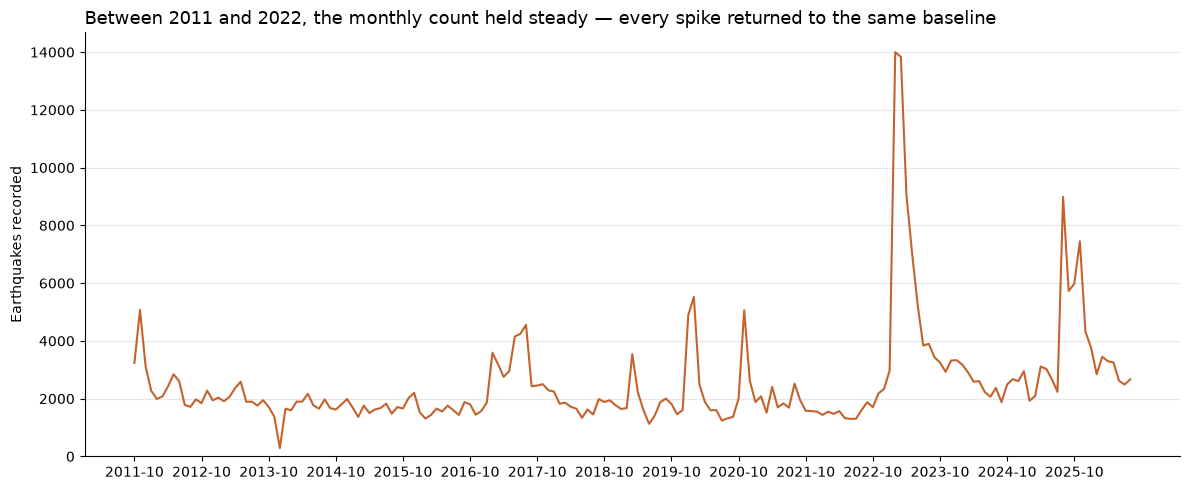

In [14]:
plot_data = df[df["in_turkey_box"] & (df["incomplete_reason"] != "download_window")]
monthly = plot_data.groupby("ym").size()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly.values, color="#C4622D", linewidth=1.5)
ax.set_xticks(monthly.index[::12])
ax.set_ylabel("Earthquakes recorded")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.set_title("Between 2011 and 2022, the monthly count held steady — every spike returned to the same baseline", loc="left", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../docs/monthly_counts.png", dpi=150)
plt.show()

## 7. Before and after 2023

Monthly rates, inside the box, complete months only.

- The earlier period starts in 2013: this comparison depends on magnitude values, and 2011–2012 mix Md and ML (Decision 2).
- 2023 is left out: it is the mainshock year itself, the source of the question rather than an answer to it.

In [15]:
tr2 = df[df["in_turkey_box"] & (df["incomplete_reason"] == "complete")]

pre = tr2[(tr2["ym"] >= "2013-01") & (tr2["ym"] <= "2022-12")]
post = tr2[tr2["ym"] >= "2024-01"]

for name, sub in [("pre", pre), ("post", post)]:
    months = sub["ym"].nunique()
    print(name, "-", months, "months")
    print("   all events / month:", round(len(sub) / months))
    print("   M>=3.0   / month:", round((sub["Magnitude"] >= 3).sum() / months))

pre - 119 months
   all events / month: 1987
   M>=3.0   / month: 73
post - 32 months
   all events / month: 3306
   M>=3.0   / month: 92


In [16]:
for name, sub in [("pre", pre), ("post", post)]:
    m = sub["ym"].nunique()
    print(name, "M<3 per month:", round((sub["Magnitude"] < 3).sum() / m))

pre M<3 per month: 1915
post M<3 per month: 3215


## 8. Magnitude–frequency distribution

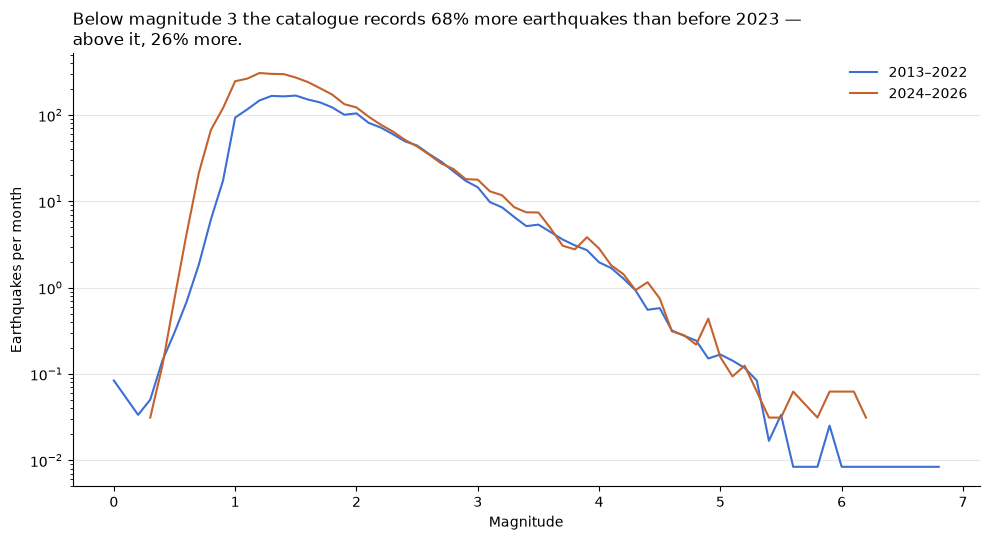

In [17]:
fig, ax = plt.subplots(figsize=(10, 5.5))
for name, sub, colour in [("2013–2022", pre, "#3B6FD4"), ("2024–2026", post, "#C4622D")]:
    rate = sub["Magnitude"].round(1).value_counts().sort_index() / sub["ym"].nunique()
    ax.plot(rate.index, rate.values, color=colour, linewidth=1.5, label=name)

ax.set_yscale("log")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Earthquakes per month")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title(
    "Below magnitude 3 the catalogue records 68% more earthquakes than before 2023 —\nabove it, 26% more.",
    loc="left", fontsize=12
)
plt.tight_layout()
plt.savefig("../docs/magnitude_frequency.png", dpi=150)
plt.show()

## 9. What drives the 26%?

In [18]:
big = tr2[tr2["Magnitude"] >= 3]
rate = big.groupby("year").size() / tr2.groupby("year")["ym"].nunique()
print(rate.round(0))

year
2011    887.0
2012    228.0
2013    129.0
2014     51.0
2015     48.0
2016     40.0
2017    110.0
2018     46.0
2019     59.0
2020    124.0
2021     73.0
2022     50.0
2023    391.0
2024     75.0
2025    127.0
2026     63.0
dtype: float64


In [19]:
aug = tr2[tr2["ym"] == "2025-08"]
print(aug.nlargest(3, "Magnitude")[["Date", "Magnitude", "Location"]])

                      Date  Magnitude              Location
59773  2025-08-10 19:53:46        6.1  Sındırgı (Balıkesir)
53416  2025-08-24 21:58:18        4.8  Sındırgı (Balıkesir)
59770  2025-08-10 20:01:21        4.6  Sındırgı (Balıkesir)


In [21]:
post_wo_2025 = post[post["year"] != 2025]
print(round((post_wo_2025["Magnitude"] >= 3).sum() / post_wo_2025["ym"].nunique()))

70


## Conclusion

The catalogue now records far more earthquakes than it used to, but that is not
the same as more earthquakes happening.

- **Below magnitude 3, the monthly count rose 68%** from 2013–2022 to 2024–2026.
  Aftershocks cannot explain this: they come in every size, so they would have
  raised the count above magnitude 3 by a similar amount. The rise comes from
  small earthquakes entering the catalogue — events that were happening before
  but were not being recorded.
- **Above magnitude 3, the count rose 26%, and all of it comes from a single
  sequence:** Sındırgı (Balıkesir), M6.1, 10 August 2025. Without 2025, the later
  period averages 70 events a month, against 73 before.
- **So the records are increasing. Whether earthquakes are increasing cannot be
  answered from these totals** — that would need a catalogue whose detection and
  magnitude scales stayed the same over time. In the one band where the catalogue
  is comparable, above magnitude 3, there is no evidence of an increase.

**Limitation.** The later period is only 32 months long and follows the largest
earthquake in the catalogue. Above magnitude 3 the rate is driven by individual
sequences, so a window this short can move a long way on a single event.